# Project 1: Statistical Analysis on Weather Data

In this project, we apply what we have learned in the previous modules to perform a complete statistical analysis on a synthetic dataset of daily temperatures. We cover:
1. Data Generation
2. Basic Statistics
3. Advanced Indexing (Filtering)
4. Finding Extremes
5. File I/O (Saving & Loading)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate 365 days of temperature data (normally distributed around 28°C with standard dev of 5°C)
# Round to 1 decimal place for realism
temperatures = np.round(np.random.normal(loc=28, scale=5, size=365), 1)

print("First 10 days temperatures:", temperatures[:10])

First 10 days temperatures: [30.5 27.3 31.2 35.6 26.8 26.8 35.9 31.8 25.7 30.7]


## 1. Basic Statistics
Let's find out the general characteristics of our weather data for the year.

In [3]:
print("--- Basic Statistics ---")

mean_temp = np.mean(temperatures)
median_temp = np.median(temperatures)
std_temp = np.std(temperatures)
min_temp = np.min(temperatures)
max_temp = np.max(temperatures)

print(f"Mean: {mean_temp:.2f}°C")
print(f"Median: {median_temp}°C")
print(f"Standard Deviation: {std_temp:.2f}°C")
print(f"Minimum: {min_temp}°C")
print(f"Maximum: {max_temp}°C")

--- Basic Statistics ---
Mean: 28.05°C
Median: 28.3°C
Standard Deviation: 4.74°C
Minimum: 11.8°C
Maximum: 47.3°C


## 2. Advanced Indexing (Filtering Data)
Find specific conditions in our dataset using boolean indexing.

In [4]:
print("--- Filtering Data ---")

# 1. How many days had temperatures above 30°C?
hot_days_mask = temperatures > 30
hot_days_count = temperatures[hot_days_mask].size
print(f"Number of days above 30°C: {hot_days_count} days")

# 2. Extract an array of all temperatures that were below 20°C.
cold_days_mask = temperatures < 20
cold_temperatures = temperatures[cold_days_mask]
print(f"Temperatures below 20°C: {cold_temperatures}")
print(f"Total cold days: {cold_temperatures.size} days")

--- Filtering Data ---
Number of days above 30°C: 118 days
Temperatures below 20°C: [18.4 19.4 18.2 19.2 14.9 18.1 18.4 18.7 19.9 17.9 11.8 18.2]
Total cold days: 12 days


## 3. Finding Extremes
Find exactly *when* the hottest and coldest days occurred.

In [5]:
print("--- Extreme Days ---")

# Find the indices (day of the year) of the hottest and coldest days
hottest_day_index = np.argmax(temperatures)
coldest_day_index = np.argmin(temperatures)

# Note: +1 is added because index starts from 0, but days start from 1
print(f"Hottest day of the year was day {hottest_day_index + 1} with {temperatures[hottest_day_index]}°C")
print(f"Coldest day of the year was day {coldest_day_index + 1} with {temperatures[coldest_day_index]}°C")

--- Extreme Days ---
Hottest day of the year was day 210 with 47.3°C
Coldest day of the year was day 263 with 11.8°C


## 4. File I/O
Save our generated dataset to a text file and load it back, to simulate saving and loading real datasets.

In [6]:
print("--- File I/O ---")

# 1. Save the 'temperatures' array to a file named 'weather_data.csv'
np.savetxt('weather_data.csv', temperatures, delimiter=',', fmt='%.1f')
print("Data successfully saved to 'weather_data.csv'")

# 2. Load the data back into a new variable 'loaded_temperatures'
loaded_temperatures = np.loadtxt('weather_data.csv', delimiter=',')
print("Data successfully loaded from 'weather_data.csv'")

# 3. Verify they are exactly the same
is_identical = np.array_equal(temperatures, loaded_temperatures)
print(f"Is the loaded data exactly the same as original? {is_identical}")

--- File I/O ---
Data successfully saved to 'weather_data.csv'
Data successfully loaded from 'weather_data.csv'
Is the loaded data exactly the same as original? True


## 5. Bonus: Visualization
Let's plot the data to see our year of temperatures!

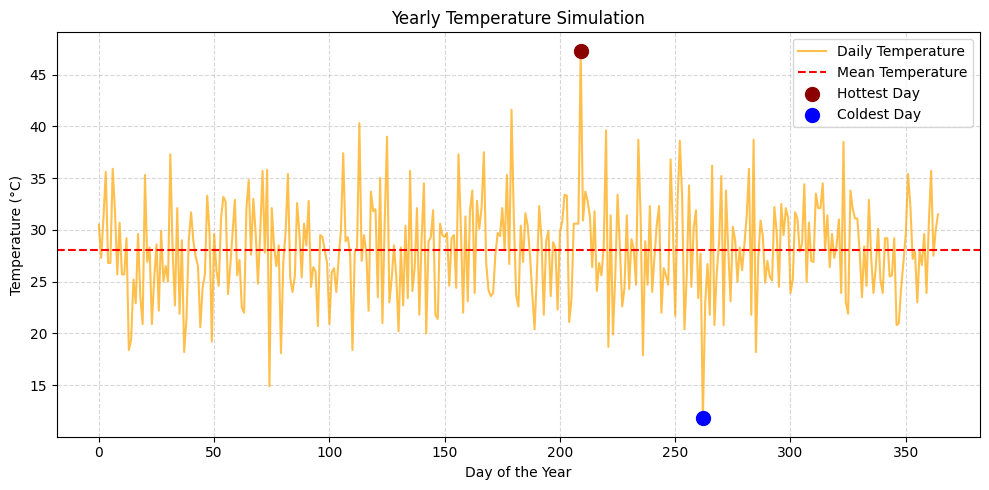

In [7]:
# Visualize the data
plt.figure(figsize=(10, 5))
plt.plot(temperatures, label="Daily Temperature", color="orange", alpha=0.7)
plt.axhline(np.mean(temperatures), color='red', linestyle='--', label="Mean Temperature")
plt.scatter(hottest_day_index, temperatures[hottest_day_index], color='darkred', s=100, label="Hottest Day", zorder=5)
plt.scatter(coldest_day_index, temperatures[coldest_day_index], color='blue', s=100, label="Coldest Day", zorder=5)

plt.title("Yearly Temperature Simulation")
plt.xlabel("Day of the Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()